# CodeAlpha Data Analytics Internship — Task 4
## Sentiment Analysis
### Project: Restaurant Reviews Dataset

This notebook covers Task 4 of the CodeAlpha Data Analytics internship: classifying
review text as Positive, Negative, or Neutral using NLP techniques, and validating
those predictions against actual star ratings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 6)

## 1. Load & Clean the Data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/restaurant_reviews.csv")
print("Raw shape:", df.shape)
df.head()


Raw shape: (658, 8)


,review_id,restaurant_name,cuisine_type,city,rating,review_text,review_length,review_date
0,1,The Burger Joint,American,Bengaluru,5,"Fresh ingredients and bold flavors, highly rec...",121,2025-05-15
1,2,Green Leaf Cafe,Vegan,Mumbai,3,"Reasonable prices, the menu could use more var...",58,2023-07-29
2,3,Smoky BBQ Pit,American,Mumbai,4,The food was absolutely delicious and beautifu...,108,2024-12-05
3,4,Coastal Kitchen,Seafood,Chennai,4,"Great spot for a family dinner, kids loved it ...",107,2023-06-11
4,5,Rustic Oven,Italian,Bengaluru,4,The food was absolutely delicious and beautifu...,60,2024-01-29


In [3]:
# Data cleaning
df_clean = df.copy()
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")
df_clean = df_clean.drop_duplicates()
df_clean = df_clean[df_clean["review_text"].notna() & (df_clean["review_text"].str.strip() != "")]
df_clean["city"] = df_clean["city"].fillna("Unknown")
df_clean["review_date"] = pd.to_datetime(df_clean["review_date"])
df_clean = df_clean.dropna(subset=["rating"])
df_clean["rating"] = df_clean["rating"].astype(int)

print("Cleaned shape:", df_clean.shape)
df_clean.head()


Cleaned shape: (645, 8)


,review_id,restaurant_name,cuisine_type,city,rating,review_text,review_length,review_date
0,1,The Burger Joint,American,Bengaluru,5,"Fresh ingredients and bold flavors, highly rec...",121,2025-05-15
1,2,Green Leaf Cafe,Vegan,Mumbai,3,"Reasonable prices, the menu could use more var...",58,2023-07-29
2,3,Smoky BBQ Pit,American,Mumbai,4,The food was absolutely delicious and beautifu...,108,2024-12-05
3,4,Coastal Kitchen,Seafood,Chennai,4,"Great spot for a family dinner, kids loved it ...",107,2023-06-11
4,5,Rustic Oven,Italian,Bengaluru,4,The food was absolutely delicious and beautifu...,60,2024-01-29


## 2. Sentiment Classification with VADER

We use **VADER** (Valence Aware Dictionary and sEntiment Reasoner), a lexicon-based
sentiment tool well suited to short-form text like reviews. Each review's compound
sentiment score maps to Positive / Neutral / Negative.

In [4]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return 'Positive', score
    elif score <= -0.05:
        return 'Negative', score
    else:
        return 'Neutral', score

results = df_clean['review_text'].apply(get_sentiment)
df_clean['sentiment'] = results.apply(lambda x: x[0])
df_clean['sentiment_score'] = results.apply(lambda x: x[1])
df_clean[['review_text', 'rating', 'sentiment', 'sentiment_score']].head(10)

,review_text,rating,sentiment,sentiment_score
0,"Fresh ingredients and bold flavors, highly rec...",5,Positive,0.9311
1,"Reasonable prices, the menu could use more var...",3,Neutral,0.0000
2,The food was absolutely delicious and beautifu...,4,Positive,0.8384
3,"Great spot for a family dinner, kids loved it ...",4,Positive,0.8934
4,The food was absolutely delicious and beautifu...,4,Positive,0.8384
5,"Average experience overall, might try another ...",3,Neutral,0.0000
6,"Best meal I've had in months, will definitely ...",5,Positive,0.9199
7,"A hidden gem, the flavors were authentic and c...",5,Positive,0.4019
8,"Not the best, not the worst, a fairly typical ...",3,Neutral,-0.0191
9,The food was absolutely delicious and beautifu...,4,Positive,0.8991


## 3. Overall Sentiment Distribution

sentiment
Positive    428
Neutral     157
Negative     60
Name: count, dtype: int64
sentiment
Positive    66.4
Neutral     24.3
Negative     9.3
Name: count, dtype: float64


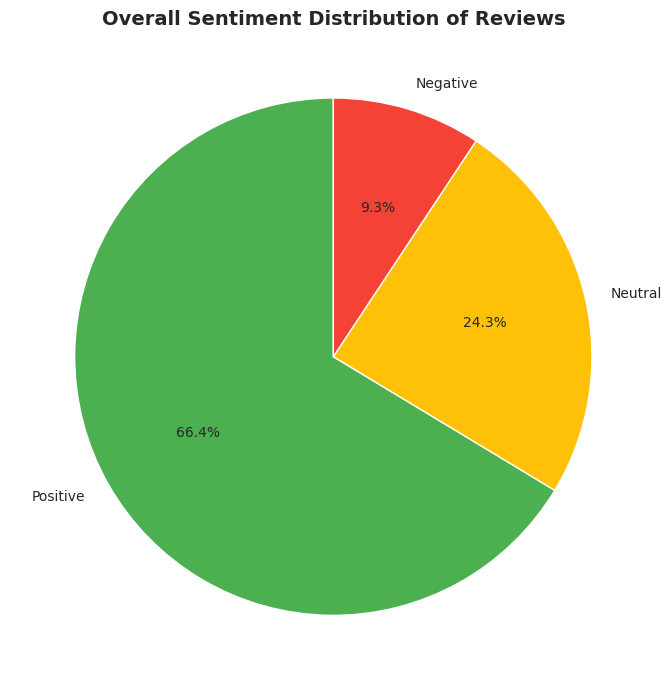

In [5]:
sentiment_counts = df_clean['sentiment'].value_counts()
print(sentiment_counts)
print((sentiment_counts / sentiment_counts.sum() * 100).round(1))

plt.figure(figsize=(7, 7))
colors = {'Positive': '#4CAF50', 'Neutral': '#FFC107', 'Negative': '#F44336'}
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=[colors[s] for s in sentiment_counts.index], startangle=90)
plt.title('Overall Sentiment Distribution of Reviews', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/07_sentiment_distribution.png', dpi=150)
plt.show()

## 4. Validating Sentiment Against Star Ratings

Does the text-based sentiment prediction agree with what the customer actually rated?

In [6]:
def rating_to_expected_sentiment(r):
    if r >= 4:
        return 'Positive'
    elif r == 3:
        return 'Neutral'
    else:
        return 'Negative'

df_clean['expected_sentiment'] = df_clean['rating'].apply(rating_to_expected_sentiment)
agreement = (df_clean['sentiment'] == df_clean['expected_sentiment']).mean()
print(f'Agreement between VADER sentiment and star rating: {agreement:.1%}')

Agreement between VADER sentiment and star rating: 69.1%


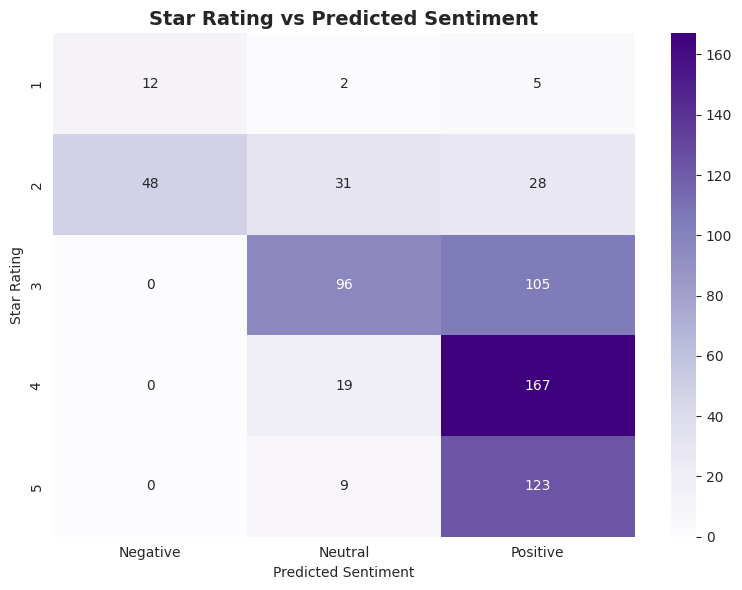

In [7]:
cross = pd.crosstab(df_clean['rating'], df_clean['sentiment'])
plt.figure(figsize=(8, 6))
sns.heatmap(cross, annot=True, fmt='d', cmap='Purples')
plt.title('Star Rating vs Predicted Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Star Rating')
plt.tight_layout()
plt.savefig('../charts/08_rating_vs_sentiment.png', dpi=150)
plt.show()

## 5. Sentiment by Cuisine

Understanding which cuisine categories generate the most positive or negative language in reviews.

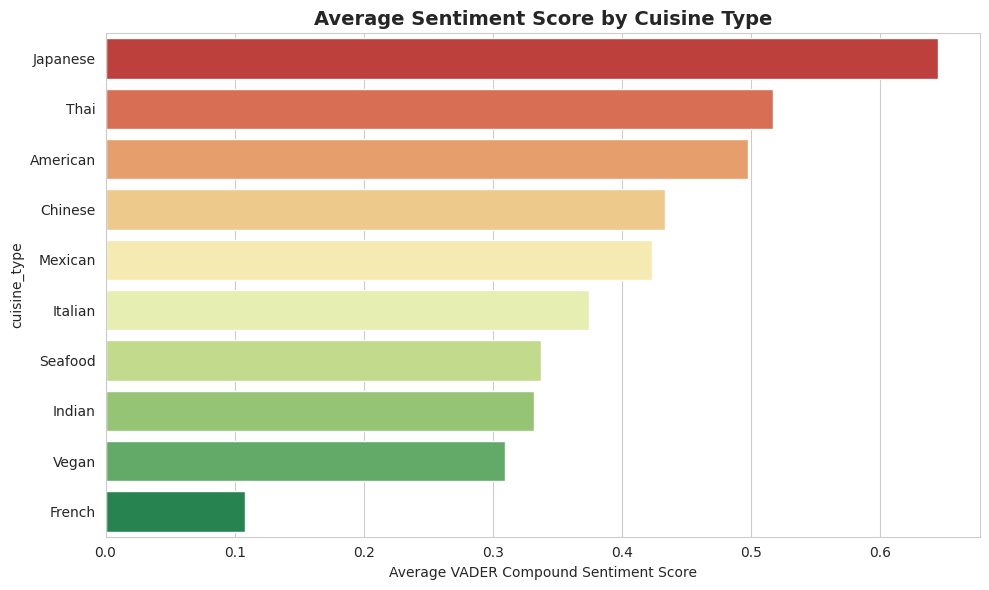

In [8]:
sentiment_by_cuisine = df_clean.groupby('cuisine_type')['sentiment_score'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=sentiment_by_cuisine.values, y=sentiment_by_cuisine.index, hue=sentiment_by_cuisine.index, palette='RdYlGn', legend=False)
ax.set_title('Average Sentiment Score by Cuisine Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Average VADER Compound Sentiment Score')
plt.tight_layout()
plt.savefig('../charts/09_sentiment_by_cuisine.png', dpi=150)
plt.show()

## 6. Sentiment Analysis Findings

- **66.4%** of reviews are Positive, **24.3%** Neutral, **9.3%** Negative.
- Predicted sentiment agrees with the star rating on **69.1%** of reviews — a solid signal
  that text sentiment is a workable proxy for satisfaction when star ratings aren't available
  (e.g. social media mentions, support tickets).
- Disagreements cluster around borderline 3-star reviews, where language can read as mildly
  positive even for an average rating.
- Sentiment score varies by cuisine, broadly tracking the average star rating findings from Task 2/3.

*This notebook covers Task 4 (Sentiment Analysis) of the CodeAlpha Data Analytics Internship.*
